In [1]:
import os
import json
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from pathlib import Path

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
TRAIN_DIR = "Downloads/SkyLark Drones/GCP_Assignment_Datasets/train_dataset"
TEST_DIR = "Downloads/SkyLark Drones/GCP_Assignment_Datasets/test_dataset"

LABEL_PATH = os.path.join(TRAIN_DIR, "curated_gcp_marks.json")

In [4]:
with open(LABEL_PATH, "r") as f:
    labels = json.load(f)

len(labels)

1000

In [5]:
for k, v in list(labels.items())[:5]:
    print(k)
    print(v)
    print()

Kemerton/240222/XLGC1028 230823/DJI_20240222135055_0537.JPG
{'mark': {'x': 2461.370441643842, 'y': 956.8182852908321}, 'verified_shape': 'Cross'}

Kemerton/240222/XLGC1028 230823/DJI_20240222135057_0538.JPG
{'mark': {'x': 2014.249835456359, 'y': 2057.4518402258336}, 'verified_shape': 'Cross'}

Kemerton/240222/XLGC1028 230823/DJI_20240222135059_0539.JPG
{'mark': {'x': 892.1149155482335, 'y': 1628.679916791009}, 'verified_shape': 'Cross'}

Kemerton/240222/XLGC1028 230823/DJI_20240222135134_0555.JPG
{'mark': {'x': 1767.5545286725478, 'y': 1760.468750026363}, 'verified_shape': 'Cross'}

Kemerton/240222/XLGC1028 230823/DJI_20240222135136_0556.JPG
{'mark': {'x': 172.42840184613488, 'y': 1941.5031266060337}, 'verified_shape': 'Cross'}



In [6]:
records = []

for img_path, info in labels.items():

    mark = info.get("mark", {})
    x = mark.get("x")
    y = mark.get("y")

    shape = info.get("verified_shape")

    records.append({
        "image_path": os.path.join(TRAIN_DIR, img_path),
        "x": x,
        "y": y,
        "shape": shape
    })

df = pd.DataFrame(records)

In [7]:
df.head()

,image_path,x,y,shape
0,Downloads/SkyLark Drones/GCP_Assignment_Datase...,2461.370442,956.818285,Cross
1,Downloads/SkyLark Drones/GCP_Assignment_Datase...,2014.249835,2057.451840,Cross
2,Downloads/SkyLark Drones/GCP_Assignment_Datase...,892.114916,1628.679917,Cross
3,Downloads/SkyLark Drones/GCP_Assignment_Datase...,1767.554529,1760.468750,Cross
4,Downloads/SkyLark Drones/GCP_Assignment_Datase...,172.428402,1941.503127,Cross


In [8]:
df.isna().sum()

image_path    0
x             0
y             0
shape         3
dtype: int64

In [9]:
df = df.dropna(subset=["shape"])

In [10]:
df["shape"].value_counts()

shape
Square    892
Cross     105
Name: count, dtype: int64

In [11]:
df["shape"].unique()

array(['Cross', 'Square'], dtype=object)

In [12]:
class_weights = torch.tensor([1/105, 1/892]).to(device)

In [13]:
def crop_marker(idx, size=200):

    row = df.iloc[idx]

    img = cv2.imread(row["image_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    x, y = int(row["x"]), int(row["y"])

    x1 = max(0, x - size)
    x2 = min(w, x + size)

    y1 = max(0, y - size)
    y2 = min(h, y + size)

    crop = img[y1:y2, x1:x2]

    plt.figure(figsize=(4,4))
    plt.imshow(crop)
    plt.axis("off")
    plt.show()

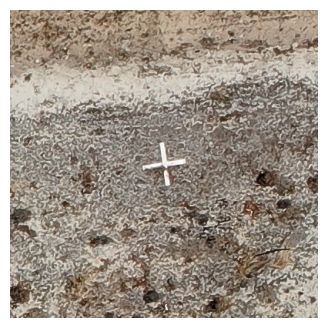

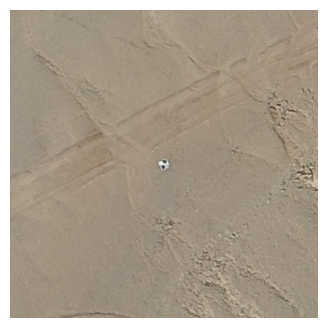

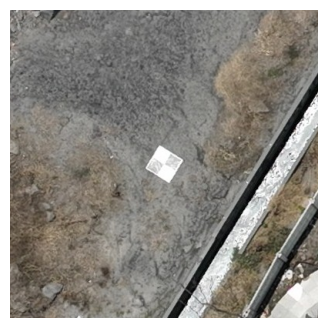

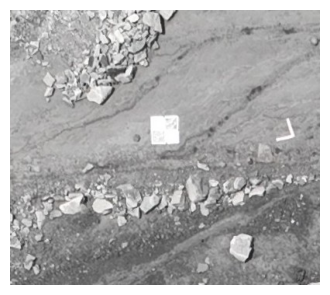

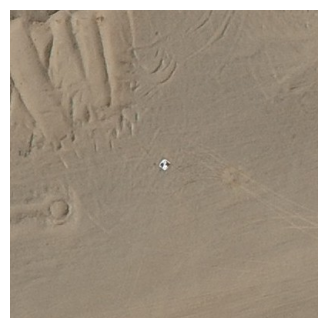

In [14]:
for i in range(5):
    crop_marker(np.random.randint(len(df)))

In [15]:
img = cv2.imread(df.iloc[0]["image_path"])
print(img.shape)

(2730, 4096, 3)


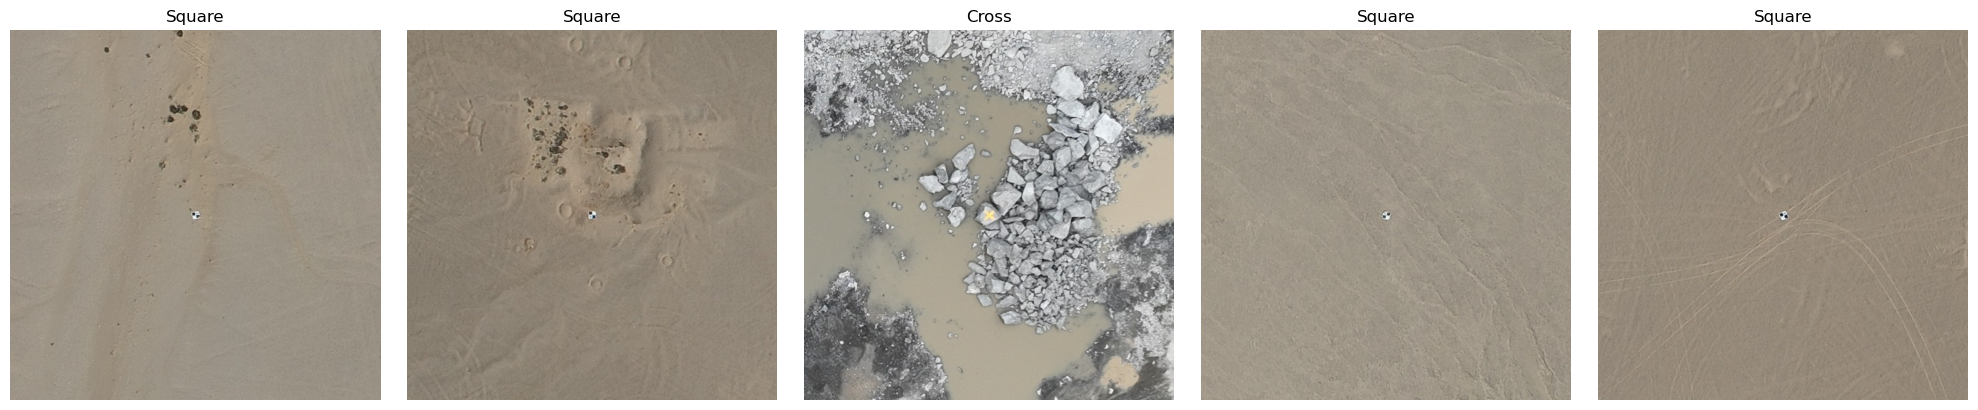

In [16]:
import random
import matplotlib.pyplot as plt
import cv2

def crop_marker(idx, size=300):

    row = df.iloc[idx]

    img = cv2.imread(row["image_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    x, y = int(row["x"]), int(row["y"])

    x1 = max(0, x-size)
    x2 = min(w, x+size)

    y1 = max(0, y-size)
    y2 = min(h, y+size)

    crop = img[y1:y2, x1:x2]

    return crop


indices = random.sample(range(len(df)), 5)

fig, axes = plt.subplots(1, 5, figsize=(20,4))

for ax, idx in zip(axes, indices):

    crop = crop_marker(idx)

    ax.imshow(crop)
    ax.set_title(df.iloc[idx]["shape"])
    ax.axis("off")

plt.tight_layout()
plt.show()

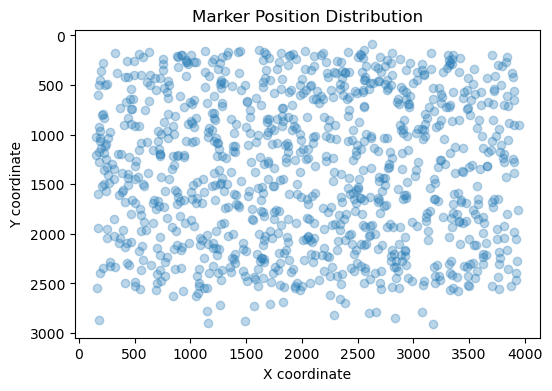

In [17]:
plt.figure(figsize=(6,4))

plt.scatter(df["x"], df["y"], alpha=0.3)

plt.title("Marker Position Distribution")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")

plt.gca().invert_yaxis()

plt.show()

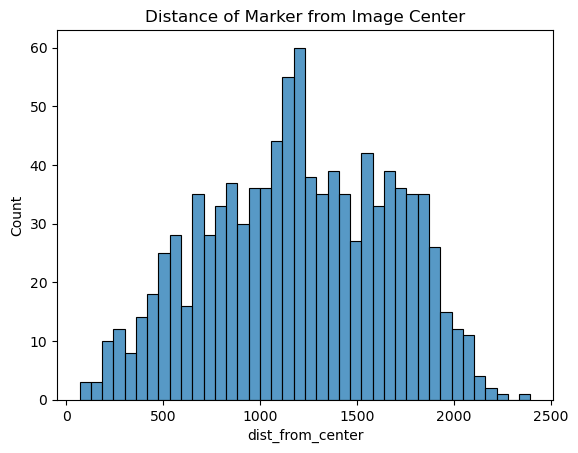

In [18]:
IMG_W = 4096
IMG_H = 2730

df["dist_from_center"] = np.sqrt(
    (df["x"] - IMG_W/2)**2 +
    (df["y"] - IMG_H/2)**2
)

sns.histplot(df["dist_from_center"], bins=40)

plt.title("Distance of Marker from Image Center")
plt.show()

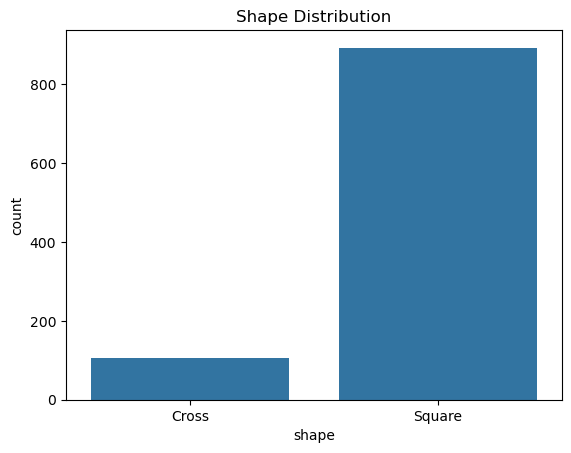

In [19]:
sns.countplot(data=df, x="shape")

plt.title("Shape Distribution")
plt.show()

In [20]:
def crop_marker(idx, size=120):

    row = df.iloc[idx]

    img = cv2.imread(row["image_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    x, y = int(row["x"]), int(row["y"])

    crop = img[y-size:y+size, x-size:x+size]

    plt.imshow(crop)
    plt.axis("off")
    plt.show()

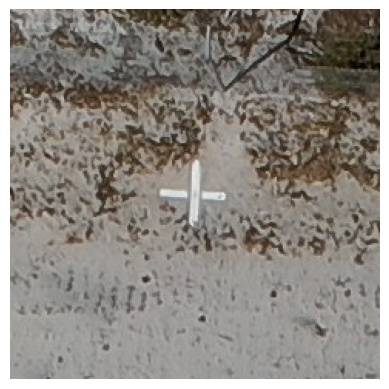

In [21]:
crop_marker(0)

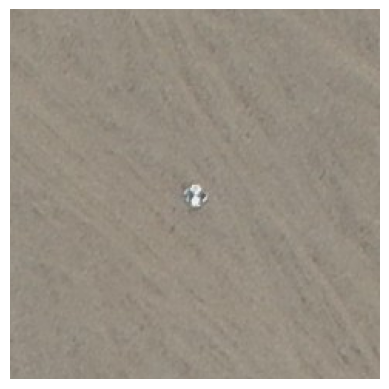

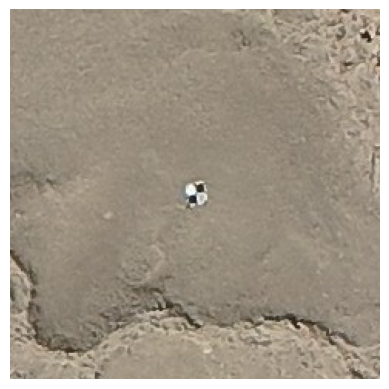

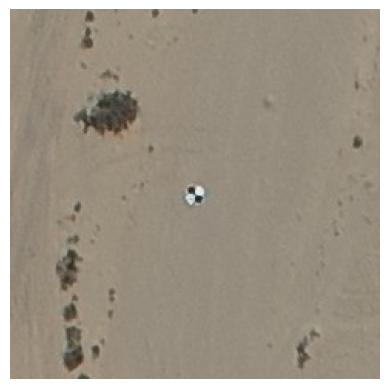

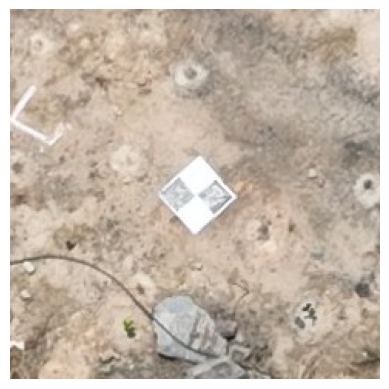

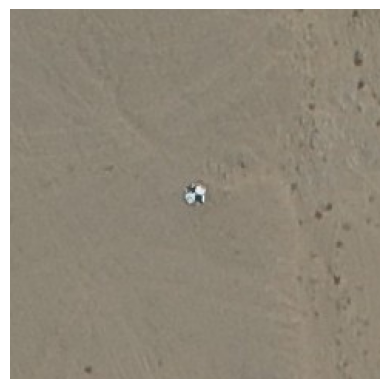

In [22]:
import random

for i in random.sample(range(len(df)), 5):
    crop_marker(i)

In [23]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["shape"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))

Train: 847
Validation: 150


In [24]:
shape_to_label = {
    "Cross": 0,
    "Square": 1
}

label_to_shape = {
    0: "Cross",
    1: "Square"
}

train_df["label"] = train_df["shape"].map(shape_to_label)
val_df["label"] = val_df["shape"].map(shape_to_label)

In [25]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256,256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

In [26]:
import torch
from torch.utils.data import Dataset
import cv2

class GCPDataset(Dataset):

    def __init__(self, dataframe, transform=None, crop_size=512):

        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.crop_size = crop_size


    def __len__(self):
        return len(self.df)


    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img = cv2.imread(row["image_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w, _ = img.shape

        x = int(row["x"])
        y = int(row["y"])

        half = self.crop_size // 2

        x1 = max(0, x-half)
        x2 = min(w, x+half)

        y1 = max(0, y-half)
        y2 = min(h, y+half)

        crop = img[y1:y2, x1:x2]

        # marker offset inside crop
        dx = (x - x1) / (x2 - x1)
        dy = (y - y1) / (y2 - y1)

        if self.transform:
            crop = self.transform(crop)

        label = row["label"]

        return crop, torch.tensor([dx,dy],dtype=torch.float32), torch.tensor(label)

In [27]:
train_dataset = GCPDataset(train_df, transform=train_transform)
val_dataset = GCPDataset(val_df, transform=val_transform)

In [28]:
from torch.utils.data import DataLoader

In [29]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

In [30]:
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [31]:
for images, coords, labels in train_loader:

    images = images.to(device)
    coords = coords.to(device)
    labels = labels.to(device)

    break

In [32]:
images, coords, labels = next(iter(train_loader))

print(images.shape)
print(coords.shape)
print(labels.shape)

torch.Size([32, 3, 256, 256])
torch.Size([32, 2])
torch.Size([32])


In [33]:
import torch.nn as nn
import torchvision.models as models

In [34]:
class GCPModel(nn.Module):

    def __init__(self):

        super().__init__()

        backbone = models.resnet18(weights="IMAGENET1K_V1")

        self.features = nn.Sequential(*list(backbone.children())[:-1])

        self.coord_head = nn.Linear(512,2)

        self.class_head = nn.Linear(512,2)


    def forward(self,x):

        x = self.features(x)

        x = x.view(x.size(0),-1)

        coords = self.coord_head(x)

        shape = self.class_head(x)

        return coords, shape

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GCPModel().to(device)

In [36]:
coord_loss = nn.MSELoss()

class_loss = nn.CrossEntropyLoss()

In [37]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
for epoch in range(10):

    model.train()

    total_loss = 0

    for images, coords, labels in train_loader:

        images = images.to(device)
        coords = coords.to(device)
        labels = labels.to(device)

        pred_coords, pred_class = model(images)

        loss1 = coord_loss(pred_coords, coords)
        loss2 = class_loss(pred_class, labels)

        loss = loss1 + loss2

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch:",epoch,"Loss:",total_loss/len(train_loader))

Epoch: 0 Loss: 0.40310335214491244
Epoch: 1 Loss: 0.08293257667510598


In [ ]:
def evaluate(model, loader):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    coord_errors = []

    with torch.no_grad():

        for images, coords, labels in loader:

            images = images.to(device)
            coords = coords.to(device)
            labels = labels.to(device)

            pred_coords, pred_class = model(images)

            loss1 = coord_loss(pred_coords, coords)
            loss2 = class_loss(pred_class, labels)

            loss = loss1 + loss2

            total_loss += loss.item()

            preds = torch.argmax(pred_class, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            error = torch.sqrt(((pred_coords - coords) ** 2).sum(dim=1))
            coord_errors.extend(error.cpu().numpy())

    acc = correct / total
    mean_coord_error = np.mean(coord_errors)

    return total_loss/len(loader), acc, mean_coord_error

In [ ]:
val_loss, val_acc, coord_err = evaluate(model, val_loader)

print("Validation Loss:", val_loss)
print("Shape Accuracy:", val_acc)
print("Mean Coord Error:", coord_err)

In [ ]:
pixel_error = coord_err * 512
print("Mean pixel error:", pixel_error)

In [ ]:
torch.save(model.state_dict(), "gcp_model.pth")

In [ ]:
class TestDataset(Dataset):

    def __init__(self, image_paths, transform=None):

        self.paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        path = self.paths[idx]

        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(img)

        return img, path

In [ ]:
from pathlib import Path

test_images = list(Path("Downloads/SkyLark Drones/GCP_Assignment_Datasets").rglob("*.JPG"))

In [ ]:
model.eval()

predictions = {}

with torch.no_grad():

    for img_path in test_images:

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w, _ = img.shape

        img_tensor = val_transform(img).unsqueeze(0).to(device)

        coords, shape_logits = model(img_tensor)

        coords = coords.cpu().numpy()[0]

        shape = torch.argmax(shape_logits, dim=1).item()

        x = float(coords[0] * w)
        y = float(coords[1] * h)

        shape_name = label_to_shape[shape]

        key = str(img_path).replace("test_dataset\\","")

        predictions[key] = {
            "mark": {"x": x, "y": y},
            "verified_shape": shape_name
        }

In [ ]:
import json

with open("predictions.json", "w") as f:
    json.dump(predictions, f, indent=4)